In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'usecase':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))


# Use Case 2: Insurance Company Bond Portfolio Downside-Rate Protection

## Business Scenario

An insurance company holds a large long-duration bond portfolio, but its liabilities are even more rate-sensitive.
In a rates rally, bond assets rise in value, but insurance liabilities may rise even more, compressing economic surplus.

To protect against this downside-rate scenario, the insurer overlays a **2Y x 10Y receiver swaption** on top of the bond portfolio.
The goal is not to maximize speculative upside, but to add convexity and reduce the deterioration in surplus when long-end rates fall.

This notebook uses a **single pricing framework only**:

- `SABR-adjusted Black`

The focus is therefore on insurance ALM strategy interpretation rather than model comparison.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from swaption_pricing.data import load_curve_points_csv
from swaption_pricing.market import load_json_metadata
from swaption_pricing.risk import parallel_shift_curve
from swaption_pricing.pricing.european import SabrParams, price_swaption_with_sabr
from swaption_pricing.core import forward_swap_rate, swap_annuity
from swaption_pricing.types import SwaptionSpec


## Market Inputs

This use case reuses the public U.S. Treasury yield-curve proxy stored in the project.
That means the benchmark-rate component is connected to real public market data, although it remains a proxy rather than a dealer-grade SOFR OIS curve.

For the volatility layer, we apply a SABR parameter set to generate a smile-aware receiver swaption premium:

- `alpha = 0.018`
- `beta = 0.50`
- `rho = -0.20`
- `nu = 0.35`

These remain illustrative rather than vendor-calibrated, but they are sufficient to build a realistic ALM overlay example.


In [3]:
curve_path = PROJECT_ROOT / 'data/european/market/ust_yield_curve_proxy/curve_points.csv'
metadata_path = PROJECT_ROOT / 'data/european/market/ust_yield_curve_proxy/ust_yield_curve_snapshot.json'

curve = load_curve_points_csv(curve_path)
curve_metadata = load_json_metadata(metadata_path)
curve_metadata


{'yield_curve_date': '2026-06-12',
 'ff_target_upper': 3.75,
 'ff_target_lower': 3.5,
 'rrp_award_rate': 3.5,
 'cpiu_latest_reading': 4.2,
 'cpiu_latest_reading_date': '2026-05-01',
 'yield_1m': 3.69,
 'yield_2m': 3.7,
 'yield_3m': 3.78,
 'yield_4m': 3.79,
 'yield_6m': 3.82,
 'yield_1y': 3.86,
 'yield_2y': 4.09,
 'yield_3y': 4.12,
 'yield_5y': 4.21,
 'yield_7y': 4.34,
 'yield_10y': 4.48,
 'yield_20y': 4.98,
 'yield_30y': 4.97,
 'recession': False}

## Insurance Portfolio and Liability Setup

We use a simplified insurance balance-sheet snapshot:

- Bond portfolio market value: `USD 500,000,000`
- Bond portfolio duration: `6.5`
- Liability present value: `USD 470,000,000`
- Liability duration: `8.5`

This implies that liabilities are more rate-sensitive than assets.
In a rates rally, both sides gain value, but liabilities gain more, which compresses economic surplus.


In [4]:
asset_market_value = 500_000_000.0
asset_duration = 6.5
liability_present_value = 470_000_000.0
liability_duration = 8.5
base_surplus = asset_market_value - liability_present_value

portfolio_df = pd.DataFrame([
    {
        'valuation_date': curve_metadata['yield_curve_date'],
        'asset_market_value': asset_market_value,
        'asset_duration': asset_duration,
        'liability_present_value': liability_present_value,
        'liability_duration': liability_duration,
        'base_surplus': base_surplus,
    }
])
portfolio_df


,valuation_date,asset_market_value,asset_duration,liability_present_value,liability_duration,base_surplus
0,2026-06-12,500000000.0,6.5,470000000.0,8.5,30000000.0


## Hedge Overlay Specification

Representative receiver swaption overlay:

- Hedge instrument: `2Y x 10Y receiver swaption`
- Swaption notional: `USD 100,000,000`
- Expiry: `2Y`
- Underlying swap tenor: `10Y`
- Strike: current ATM forward swap rate

The long-end underlying is chosen deliberately: insurance liabilities are often sensitive to longer-dated rates, so a long-tenor receiver swaption is a natural convex overlay candidate.


In [5]:
swaption_notional = 100_000_000.0
expiry = 2.0
tenor = 10.0
pay_frequency = 1
option_type = 'receiver'

atm_strike = forward_swap_rate(curve, expiry, tenor, pay_frequency)
spec = SwaptionSpec(
    notional=swaption_notional,
    expiry=expiry,
    tenor=tenor,
    strike=atm_strike,
    pay_frequency=pay_frequency,
    option_type=option_type,
)

sabr_params = SabrParams(alpha=0.018, beta=0.50, rho=-0.20, nu=0.35)
base_forward = forward_swap_rate(curve, expiry, tenor, pay_frequency)
base_annuity = swap_annuity(curve, expiry, tenor, pay_frequency)
base_price, base_sabr_vol = price_swaption_with_sabr(curve, spec, sabr_params)

hedge_setup_df = pd.DataFrame([
    {
        'swaption_notional': swaption_notional,
        'expiry_years': expiry,
        'tenor_years': tenor,
        'atm_strike': atm_strike,
        'base_forward': base_forward,
        'annuity': base_annuity,
        'sabr_implied_vol': base_sabr_vol,
        'base_swaption_premium': base_price,
    }
])
hedge_setup_df


,swaption_notional,expiry_years,tenor_years,atm_strike,base_forward,annuity,sabr_implied_vol,base_swaption_premium
0,100000000.0,2.0,10.0,0.047481,0.047481,7.250883,0.084084,1.632264e+06


## Key Modelling Assumptions

The main simplifying assumptions in this insurance strategy example are:

- `Asset and liability sensitivity`: modeled primarily through duration rather than full cash-flow or key-rate decomposition
- `Benchmark-rate focus`: the balance-sheet response is driven by benchmark-rate shifts, not issuer spread or credit migration dynamics
- `Overlay sizing`: the receiver swaption notional is fixed for illustration rather than optimized to a target surplus DV01 or solvency metric
- `Volatility layer`: SABR parameters are illustrative and not calibrated to a live receiver smile slice
- `Scenario engine`: rate moves are modeled as parallel shifts to the curve rather than full non-parallel curve paths

These assumptions are acceptable for a first-pass ALM overlay study, but a production insurance hedging framework would refine them materially.


## Scenario Design

We analyze three broad rate regimes, each with **5 rate points**:

- `Falling`: rates decline steadily and create downside pressure on insurance surplus
- `Unchanged`: rates remain near the current level
- `Rising`: rates move higher and relieve some liability pressure

For each scenario point we compute:

1. Asset value change
2. Liability value change
3. Surplus change without hedge
4. Receiver swaption PnL
5. Surplus change after hedge


In [6]:
scenario_definitions = {
    'falling': [-0.0100, -0.0075, -0.0050, -0.0025, -0.0010],
    'unchanged': [-0.0010, -0.0005, 0.0000, 0.0005, 0.0010],
    'rising': [0.0010, 0.0025, 0.0050, 0.0075, 0.0100],
}

scenario_rows = []
for regime, shocks in scenario_definitions.items():
    for idx, shock in enumerate(shocks, start=1):
        shocked_curve = parallel_shift_curve(curve, shock)
        shocked_forward = forward_swap_rate(shocked_curve, expiry, tenor, pay_frequency)
        shocked_price, shocked_sabr_vol = price_swaption_with_sabr(shocked_curve, spec, sabr_params)
        swaption_pnl = shocked_price - base_price
        asset_value_change = -asset_duration * asset_market_value * shock
        liability_value_change = -liability_duration * liability_present_value * shock
        surplus_change_unhedged = asset_value_change - liability_value_change
        surplus_change_hedged = surplus_change_unhedged + swaption_pnl
        scenario_rows.append({
            'regime': regime,
            'scenario_point': idx,
            'rate_shift_bp': shock * 10000,
            'future_forward_proxy': shocked_forward,
            'asset_value_change': asset_value_change,
            'liability_value_change': liability_value_change,
            'surplus_change_unhedged': surplus_change_unhedged,
            'swaption_pnl': swaption_pnl,
            'sabr_implied_vol': shocked_sabr_vol,
            'surplus_change_hedged': surplus_change_hedged,
        })

scenario_df = pd.DataFrame(scenario_rows)
scenario_df


,regime,scenario_point,rate_shift_bp,future_forward_proxy,asset_value_change,liability_value_change,surplus_change_unhedged,swaption_pnl,sabr_implied_vol,surplus_change_hedged
0,falling,1,-100.0,0.037145,32500000.0,39950000.0,-7450000.0,6.472416e+06,0.093884,-9.775837e+05
1,falling,2,-75.0,0.039719,24375000.0,29962500.0,-5587500.0,4.452292e+06,0.089003,-1.135208e+06
2,falling,3,-50.0,0.042300,16250000.0,19975000.0,-3725000.0,2.631101e+06,0.085663,-1.093899e+06
3,falling,4,-25.0,0.044887,8125000.0,9987500.0,-1862500.0,1.117093e+06,0.084037,-7.454066e+05
4,falling,5,-10.0,0.046442,3250000.0,3995000.0,-745000.0,3.968600e+05,0.083879,-3.481400e+05
5,unchanged,1,-10.0,0.046442,3250000.0,3995000.0,-745000.0,3.968600e+05,0.083879,-3.481400e+05
6,unchanged,2,-5.0,0.046961,1625000.0,1997500.0,-372500.0,1.901867e+05,0.083952,-1.823133e+05
7,unchanged,3,0.0,0.047481,-0.0,-0.0,0.0,0.000000e+00,0.084084,0.000000e+00
8,unchanged,4,5.0,0.048000,-1625000.0,-1997500.0,372500.0,-1.741098e+05,0.084271,1.983902e+05
9,unchanged,5,10.0,0.048520,-3250000.0,-3995000.0,745000.0,-3.327145e+05,0.084511,4.122855e+05


## Scenario Tables by Regime


In [7]:
for regime_name in ['falling', 'unchanged', 'rising']:
    display(scenario_df[scenario_df['regime'] == regime_name].reset_index(drop=True))


,regime,scenario_point,rate_shift_bp,future_forward_proxy,asset_value_change,liability_value_change,surplus_change_unhedged,swaption_pnl,sabr_implied_vol,surplus_change_hedged
0,falling,1,-100.0,0.037145,32500000.0,39950000.0,-7450000.0,6.472416e+06,0.093884,-9.775837e+05
1,falling,2,-75.0,0.039719,24375000.0,29962500.0,-5587500.0,4.452292e+06,0.089003,-1.135208e+06
2,falling,3,-50.0,0.042300,16250000.0,19975000.0,-3725000.0,2.631101e+06,0.085663,-1.093899e+06
3,falling,4,-25.0,0.044887,8125000.0,9987500.0,-1862500.0,1.117093e+06,0.084037,-7.454066e+05
4,falling,5,-10.0,0.046442,3250000.0,3995000.0,-745000.0,3.968600e+05,0.083879,-3.481400e+05


,regime,scenario_point,rate_shift_bp,future_forward_proxy,asset_value_change,liability_value_change,surplus_change_unhedged,swaption_pnl,sabr_implied_vol,surplus_change_hedged
0,unchanged,1,-10.0,0.046442,3250000.0,3995000.0,-745000.0,396859.996887,0.083879,-348140.003113
1,unchanged,2,-5.0,0.046961,1625000.0,1997500.0,-372500.0,190186.655336,0.083952,-182313.344664
2,unchanged,3,0.0,0.047481,-0.0,-0.0,0.0,0.000000,0.084084,0.000000
3,unchanged,4,5.0,0.048000,-1625000.0,-1997500.0,372500.0,-174109.800979,0.084271,198390.199021
4,unchanged,5,10.0,0.048520,-3250000.0,-3995000.0,745000.0,-332714.489385,0.084511,412285.510615


,regime,scenario_point,rate_shift_bp,future_forward_proxy,asset_value_change,liability_value_change,surplus_change_unhedged,swaption_pnl,sabr_implied_vol,surplus_change_hedged
0,rising,1,10.0,0.048520,-3250000.0,-3995000.0,745000.0,-3.327145e+05,0.084511,4.122855e+05
1,rising,2,25.0,0.050081,-8125000.0,-9987500.0,1862500.0,-7.230760e+05,0.085504,1.139424e+06
2,rising,3,50.0,0.052687,-16250000.0,-19975000.0,3725000.0,-1.143399e+06,0.087876,2.581601e+06
3,rising,4,75.0,0.055300,-24375000.0,-29962500.0,5587500.0,-1.371919e+06,0.090817,4.215581e+06
4,rising,5,100.0,0.057920,-32500000.0,-39950000.0,7450000.0,-1.492521e+06,0.094053,5.957479e+06


## Visuals for Insurance ALM Interpretation

The most useful visuals in this strategy context are:

1. `Asset vs liability value change`
2. `Unhedged surplus change`
3. `Receiver swaption PnL`
4. `Surplus before hedge vs after hedge`


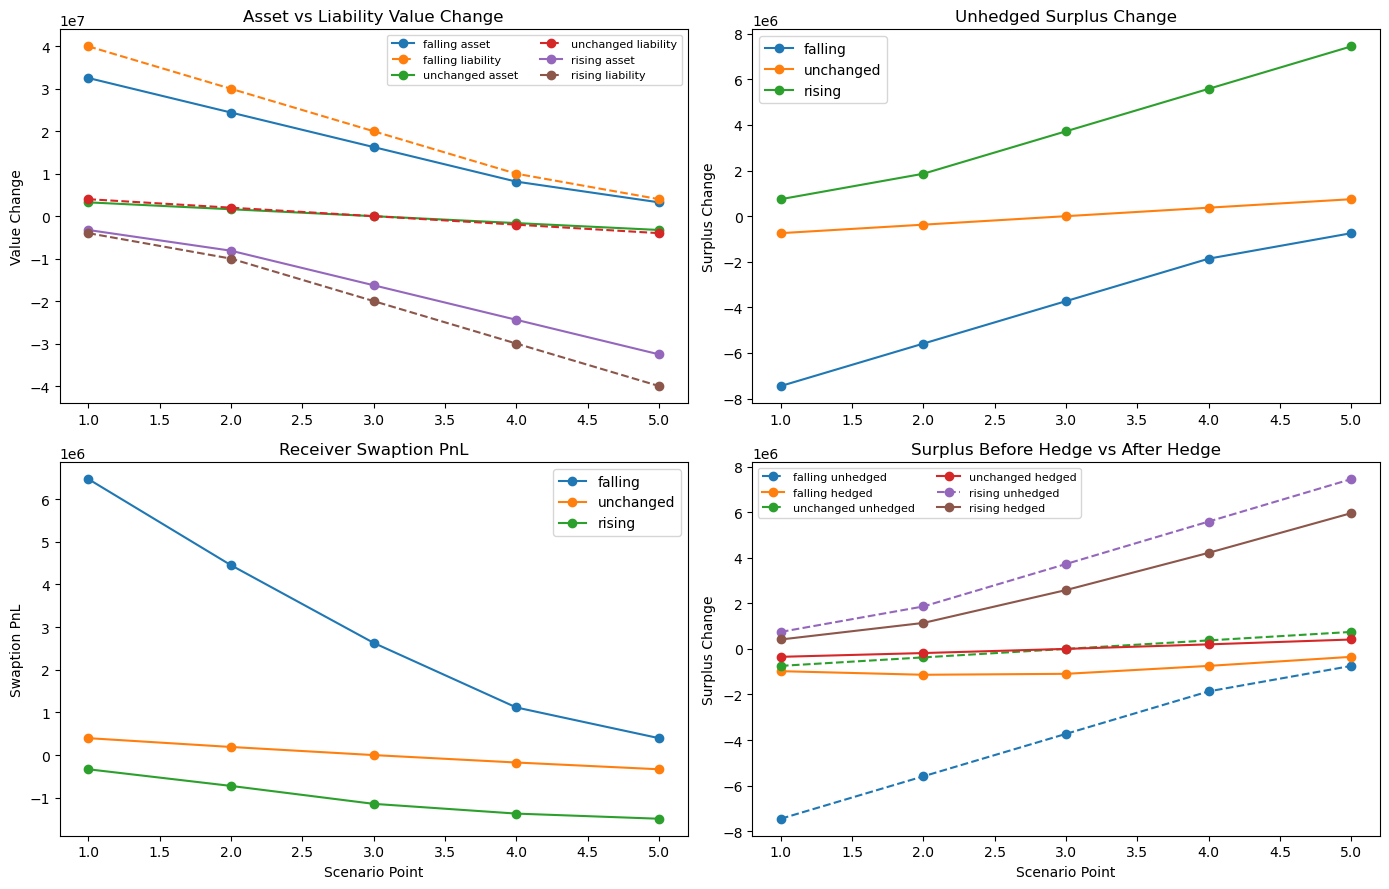

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)

for regime_name in ['falling', 'unchanged', 'rising']:
    subset = scenario_df[scenario_df['regime'] == regime_name]
    axes[0, 0].plot(subset['scenario_point'], subset['asset_value_change'], marker='o', label=f'{regime_name} asset')
    axes[0, 0].plot(subset['scenario_point'], subset['liability_value_change'], marker='o', linestyle='--', label=f'{regime_name} liability')
    axes[0, 1].plot(subset['scenario_point'], subset['surplus_change_unhedged'], marker='o', label=regime_name)
    axes[1, 0].plot(subset['scenario_point'], subset['swaption_pnl'], marker='o', label=regime_name)
    axes[1, 1].plot(subset['scenario_point'], subset['surplus_change_unhedged'], marker='o', linestyle='--', label=f'{regime_name} unhedged')
    axes[1, 1].plot(subset['scenario_point'], subset['surplus_change_hedged'], marker='o', label=f'{regime_name} hedged')

axes[0, 0].set_title('Asset vs Liability Value Change')
axes[0, 0].set_ylabel('Value Change')
axes[0, 0].legend(ncol=2, fontsize=8)

axes[0, 1].set_title('Unhedged Surplus Change')
axes[0, 1].set_ylabel('Surplus Change')
axes[0, 1].legend()

axes[1, 0].set_title('Receiver Swaption PnL')
axes[1, 0].set_ylabel('Swaption PnL')
axes[1, 0].set_xlabel('Scenario Point')
axes[1, 0].legend()

axes[1, 1].set_title('Surplus Before Hedge vs After Hedge')
axes[1, 1].set_ylabel('Surplus Change')
axes[1, 1].set_xlabel('Scenario Point')
axes[1, 1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


## Falling-Rate Focus: Does the Overlay Protect Economic Surplus?

The most important regime for this insurance use case is the `falling` set, because that is where liability revaluation pressure is strongest.
Below we isolate those scenarios and measure how much of the unhedged surplus deterioration is offset by the receiver swaption.


In [9]:
falling_df = scenario_df[scenario_df['regime'] == 'falling'].copy()
falling_df['hedge_support_ratio'] = falling_df['swaption_pnl'] / (-falling_df['surplus_change_unhedged'])
falling_df[['scenario_point', 'rate_shift_bp', 'surplus_change_unhedged', 'swaption_pnl', 'surplus_change_hedged', 'hedge_support_ratio']]


,scenario_point,rate_shift_bp,surplus_change_unhedged,swaption_pnl,surplus_change_hedged,hedge_support_ratio
0,1,-100.0,-7450000.0,6.472416e+06,-9.775837e+05,0.868781
1,2,-75.0,-5587500.0,4.452292e+06,-1.135208e+06,0.796831
2,3,-50.0,-3725000.0,2.631101e+06,-1.093899e+06,0.706336
3,4,-25.0,-1862500.0,1.117093e+06,-7.454066e+05,0.599782
4,5,-10.0,-745000.0,3.968600e+05,-3.481400e+05,0.532698


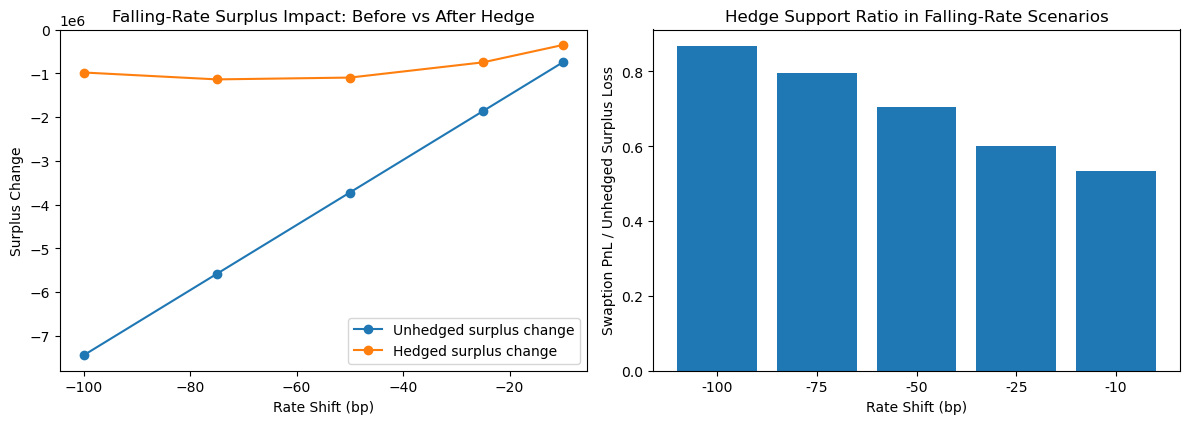

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(falling_df['rate_shift_bp'], falling_df['surplus_change_unhedged'], marker='o', label='Unhedged surplus change')
axes[0].plot(falling_df['rate_shift_bp'], falling_df['surplus_change_hedged'], marker='o', label='Hedged surplus change')
axes[0].set_title('Falling-Rate Surplus Impact: Before vs After Hedge')
axes[0].set_xlabel('Rate Shift (bp)')
axes[0].set_ylabel('Surplus Change')
axes[0].legend()

axes[1].bar(falling_df['rate_shift_bp'].astype(int).astype(str), falling_df['hedge_support_ratio'])
axes[1].set_title('Hedge Support Ratio in Falling-Rate Scenarios')
axes[1].set_xlabel('Rate Shift (bp)')
axes[1].set_ylabel('Swaption PnL / Unhedged Surplus Loss')

plt.tight_layout()
plt.show()


## Interpretation

- In the `falling` regime, liabilities revalue more strongly than assets because liability duration is assumed to be longer than asset duration.
- That creates negative unhedged surplus changes, which is the economic downside the insurance company wants to manage.
- The receiver swaption gains value when long-end rates fall, and that gain helps offset part of the surplus deterioration.
- In the `unchanged` regime, the overlay behaves more like an insurance premium with limited immediate balance-sheet benefit.
- In the `rising` regime, the insurer may not need the protection, and the swaption can underperform the unhedged case, which is consistent with the economic purpose of insurance-like protection.
- The most important output is therefore not raw option PnL, but `surplus_change_hedged` relative to `surplus_change_unhedged` in falling-rate scenarios.

## Practical Limitations

- The asset and liability sides are summarized by market value and duration rather than full cash-flow models.
- The curve is a public-data Treasury proxy, not a dealer-grade SOFR OIS curve.
- The volatility inputs are still project assumptions rather than a real market receiver smile slice.
- Credit spread risk, liability optionality, and regulatory capital metrics are not explicitly modeled.
